In [40]:
from dotenv import load_dotenv
load_dotenv()

True

In [41]:
from langchain.chat_models import init_chat_model
from langchain_core.output_parsers import StrOutputParser

llm = init_chat_model("google_genai:gemini-3.1-flash-lite")

chain = llm | StrOutputParser()

In [42]:
from typing import TypedDict

class State(TypedDict):
    topic: str
    joke: str
    story: str
    poem: str
    combined_output: str

In [43]:
def call_llm_1(state: State):
    response = chain.invoke(f"{state['topic']}에 대한 재미있는 슬랙 코미디 하나 작성해줘")
    return {"joke": response}

In [44]:
def call_llm_2(state: State):
    response = chain.invoke(f"{state['topic']}에 대한 짧은 이야기 하나 작성해줘")
    return {"story": response}

In [45]:
def call_llm_3(state: State):
    response = chain.invoke(f"{state['topic']}에 대한 멋진 하이쿠 한 편 작성해줘")
    return {"poem": response}

In [46]:
def aggregator(state: State):
    combined = f"다음은 {state["topic"]}에 대한 이야기, 농담, 그리고 시입니다.\n\n"
    combined += f"이야기: {state["story"]}\n\n"
    combined += f"농담: {state["joke"]}\n\n"
    combined += f"시: {state["poem"]}\n\n"
    return {"combined_output": combined}

In [47]:
from langgraph.graph import StateGraph, START, END

parallel_builder = StateGraph(State)

parallel_builder.add_node(call_llm_1)
parallel_builder.add_node(call_llm_2)
parallel_builder.add_node(call_llm_3)
parallel_builder.add_node(aggregator)

parallel_builder.add_edge(START, "call_llm_1")
parallel_builder.add_edge(START, "call_llm_2")
parallel_builder.add_edge(START, "call_llm_3")
parallel_builder.add_edge("call_llm_1", "aggregator")
parallel_builder.add_edge("call_llm_2", "aggregator")
parallel_builder.add_edge("call_llm_3", "aggregator")
parallel_builder.add_edge("aggregator", END)

parallel_workflow = parallel_builder.compile()

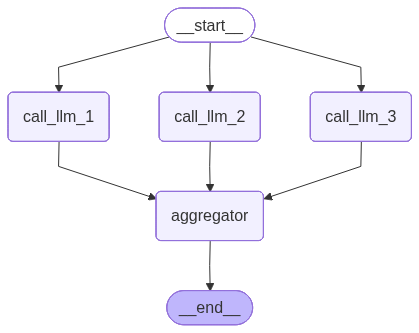

In [48]:
parallel_workflow

In [49]:
result = parallel_workflow.invoke({"topic": "고양이"})

In [50]:
print(result['combined_output'])

다음은 고양이에 대한 이야기, 농담, 그리고 시입니다.

이야기: 오래된 동네의 작은 골목 끝, 햇볕이 잘 드는 담벼락 위에는 늘 낮잠을 자는 고양이 ‘루루’가 있었습니다.

루루는 동네 사람들에게 ‘시간의 파수꾼’이라 불렸습니다. 루루가 눈을 뜨고 기지개를 켜면 아이들이 학교에서 돌아왔고, 루루가 하품을 하며 앞발을 핥으면 퇴근하는 어른들의 발소리가 들려왔기 때문입니다.

어느 비 오는 오후, 루루는 평소처럼 담벼락 위에 앉아 있었습니다. 그때, 길을 잃고 빗속에서 울고 있는 작은 강아지 한 마리가 보였습니다. 루루는 평소라면 귀찮은 듯 눈을 감았겠지만, 그날은 꼬리를 가볍게 흔들며 아래로 뛰어내렸습니다.

루루는 젖은 몸을 털며 강아지에게 다가가 따뜻한 앞발로 툭, 툭 쳤습니다. 그리고는 근처 처마 밑, 비를 피할 수 있는 아늑한 공간으로 앞장서서 걸어갔습니다. 강아지가 루루를 따라 그곳에 자리를 잡자, 루루는 강아지 곁에 몸을 웅크리고 누워 체온을 나누어 주었습니다.

비가 그치고 동네 사람들이 강아지의 주인을 찾아주었을 때, 사람들은 고양이 루루가 강아지를 돌보고 있었다는 사실에 놀라워했습니다.

그날 이후로도 루루는 변함없이 담벼락 위에 앉아 있습니다. 하지만 이제 사람들은 루루를 볼 때마다 조금 더 따뜻한 미소를 짓습니다. 동네의 작은 파수꾼이, 사실은 누구보다 다정한 마음을 가진 친구라는 것을 모두가 알게 되었으니까요.

농담: 슬랙(Slack)의 **#random** 채널에 올리기 딱 좋은, 직장인 고양이 컨셉의 코미디를 작성해 드립니다.

***

**[슬랙 메시지 예시]**

**제목: 긴급) 저희 팀 새로운 신입사원 업무 태도가 좀 불량하네요..;;**

오늘 아침부터 새로 들어온 신입이 제 책상에서 이러고 있네요. 

1. **상습 지각:** 아침 10시에 출근해서 이미 11시에 낮잠 자러 들어감.
2. **업무 방해:** 제가 타이핑하고 있으면 키보드 위에 털썩 앉아서 '야, 일 좀 그만하고 나 봐라' 눈빛으로 쳐다봄. (덕분에 오늘 오